# 03 Sen1Floods11 Ghana EDA

Explore the Ghana flood-mapping pilot dataset.

Task: binary flood segmentation.

Classes:
- 0: not flood
- 1: flood

## 1. Imports and Setup

In [5]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/Users/similoluwaokunowo/Desktop/Research/geoai-lightning-talk-research')

## 2. Load Dataset

In [6]:
from eval_harness.config import load_yaml, dataset_config_path
from eval_harness.datasets import build_dataset
from eval_harness.exploration import (
    dataset_overview,
    label_budget_summary,
    plot_class_balance,
    plot_label_budget_coverage,
    sample_table,
    segmentation_pixel_distribution,
)

cfg = load_yaml(dataset_config_path('sen1floods11_ghana'))
train_ds = build_dataset(cfg, split='train')

print('train examples:', len(train_ds))

train examples: 37


## 3. Overview

In [7]:
display(dataset_overview(cfg, train_ds))
display(sample_table(train_ds, n=5))

,name,display_name,region,theme,task_type,num_classes,input_shape,num_examples,smoke_fixture
0,sen1floods11_ghana,Sen1Floods11 Ghana,Ghana,Disaster response and humanitarian flood mapping,segmentation,2,"(13, 512, 512)",37,None


,idx,id,x_shape,x_min,x_mean,x_max,y_shape,y_preview
0,0,Ghana_103272,"(13, 512, 512)",44.0,1935.603027,5658.0,"(512, 512)","[0, 1]"
1,1,Ghana_1033830,"(13, 512, 512)",5.0,1337.231689,5303.0,"(512, 512)","[0, 1]"
2,2,Ghana_1078550,"(13, 512, 512)",39.0,1525.250854,5083.0,"(512, 512)","[0, 1]"
3,3,Ghana_1089161,"(13, 512, 512)",30.0,1789.044189,6932.0,"(512, 512)","[0, 1]"
4,4,Ghana_11745,"(13, 512, 512)",22.0,1819.779785,4629.0,"(512, 512)",[0]


## 4. Pixel Class Balance

,label,class_name,pixels,fraction
0,0,not_flood,6225483,0.989514
1,1,flood,65973,0.010486


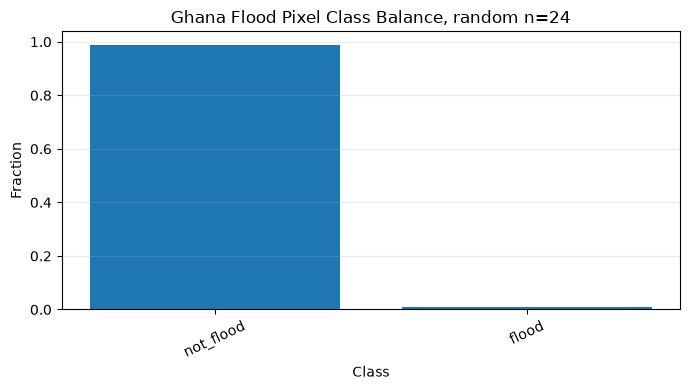

In [8]:
MAX_EXAMPLES = min(24, len(train_ds))

pixel_balance = segmentation_pixel_distribution(
    train_ds,
    cfg['class_names'],
    max_examples=MAX_EXAMPLES,
    seed=1234,
)
display(pixel_balance)
plot_class_balance(pixel_balance, value_col='fraction', title=f'Ghana Flood Pixel Class Balance, random n={MAX_EXAMPLES}');

## 5. Full Mask Pixel Balance

This computes class balance from all cached Ghana masks, not just a random sample from the train split. It is mask-only, so it is faster than loading full Sentinel-2 image tensors.


,class_name,pixels,fraction
0,not_flood,13315924,0.958419
1,flood,577708,0.041581


num masks: 53
images with flood: 27
zero-flood images: 26
median flood fraction: 1.52587890625e-05
max flood fraction: 0.5495109558105469


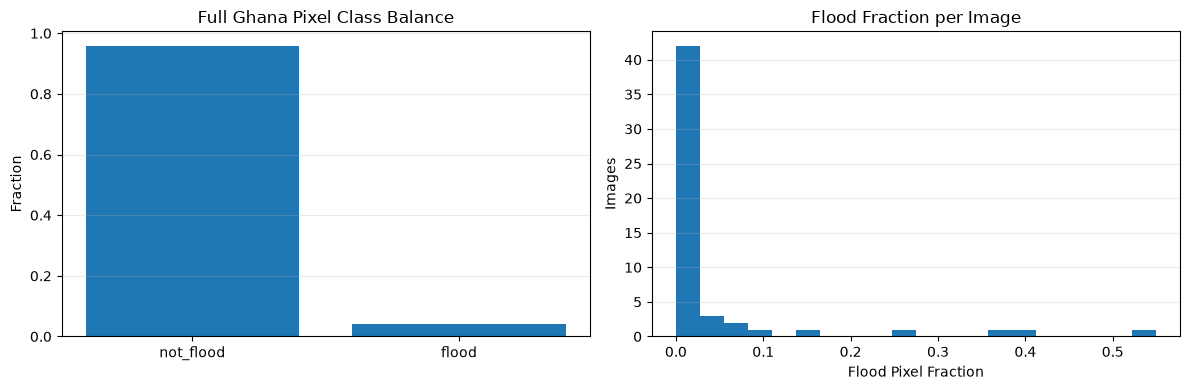

In [9]:
from pathlib import Path
import rasterio

mask_paths = sorted((PROJECT_ROOT / 'data' / 'hf_cache' / 'sen1floods11_ghana').rglob('*LabelHand.tif'))
full_rows = []
total_not_flood = 0
total_flood = 0

for path in mask_paths:
    with rasterio.open(path) as src:
        y = src.read(1)
    y = (y > 0).astype('uint8')
    flood_pixels = int((y == 1).sum())
    not_flood_pixels = int((y == 0).sum())
    total_not_flood += not_flood_pixels
    total_flood += flood_pixels
    full_rows.append({
        'id': path.name.replace('_LabelHand.tif', ''),
        'not_flood_pixels': not_flood_pixels,
        'flood_pixels': flood_pixels,
        'total_pixels': not_flood_pixels + flood_pixels,
        'flood_fraction': flood_pixels / (not_flood_pixels + flood_pixels),
        'has_flood': flood_pixels > 0,
    })

full_pixel_balance = pd.DataFrame([
    {'class_name': 'not_flood', 'pixels': total_not_flood, 'fraction': total_not_flood / (total_not_flood + total_flood)},
    {'class_name': 'flood', 'pixels': total_flood, 'fraction': total_flood / (total_not_flood + total_flood)},
])
full_image_balance = pd.DataFrame(full_rows)

display(full_pixel_balance)
print('num masks:', len(mask_paths))
print('images with flood:', int(full_image_balance['has_flood'].sum()))
print('zero-flood images:', int((~full_image_balance['has_flood']).sum()))
print('median flood fraction:', full_image_balance['flood_fraction'].median())
print('max flood fraction:', full_image_balance['flood_fraction'].max())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(full_pixel_balance['class_name'], full_pixel_balance['fraction'])
axes[0].set_title('Full Ghana Pixel Class Balance')
axes[0].set_ylabel('Fraction')
axes[0].grid(axis='y', alpha=0.25)

axes[1].hist(full_image_balance['flood_fraction'], bins=20)
axes[1].set_title('Flood Fraction per Image')
axes[1].set_xlabel('Flood Pixel Fraction')
axes[1].set_ylabel('Images')
axes[1].grid(axis='y', alpha=0.25)
fig.tight_layout()


## 6. Label-Budget Coverage

,budget,strategy,num_examples,label,class_name,pixels,fraction
0,0.10,random,4,0,not_flood,1025907,0.978381
1,0.10,random,4,1,flood,22669,0.021619
2,0.25,random,9,0,not_flood,2289694,0.970499
3,0.25,random,9,1,flood,69602,0.029501
4,1.00,random,37,0,not_flood,9400835,0.969225
5,1.00,random,37,1,flood,298493,0.030775


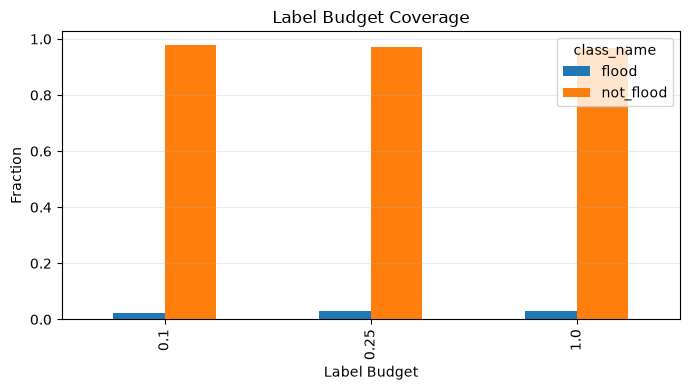

In [10]:
budget_df = label_budget_summary(
    train_ds,
    cfg,
    budgets=[0.10, 0.25, 1.00],
    seed=1234,
)
display(budget_df)
plot_label_budget_coverage(budget_df);

## 7. Visual Samples

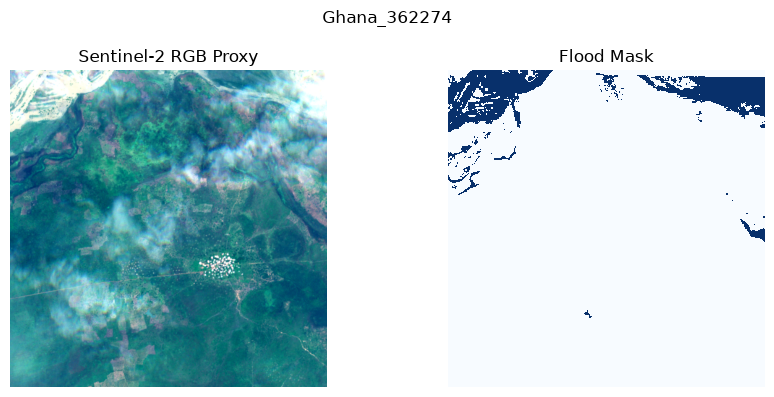

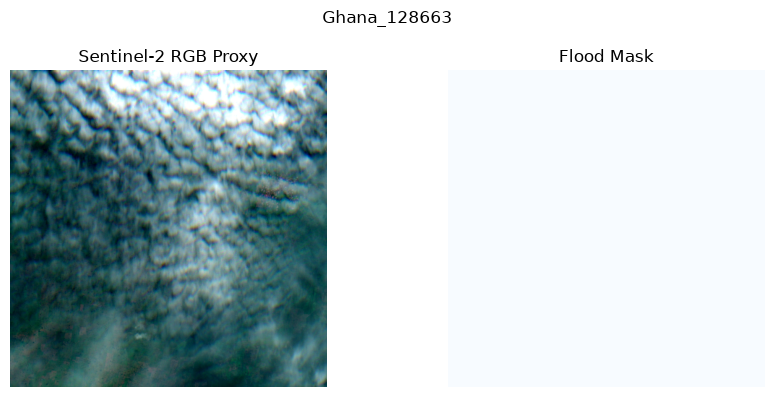

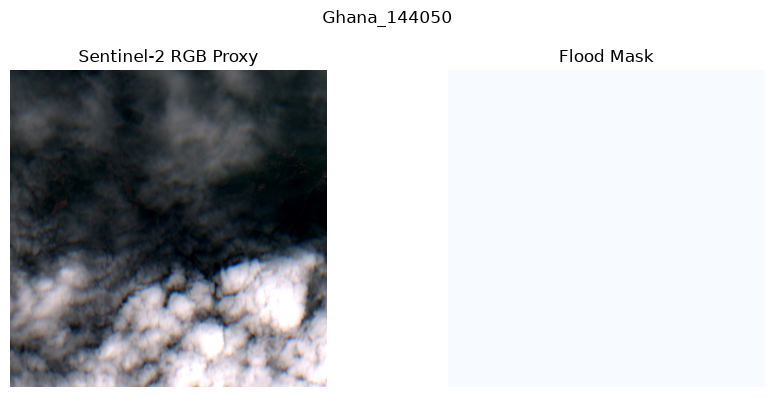

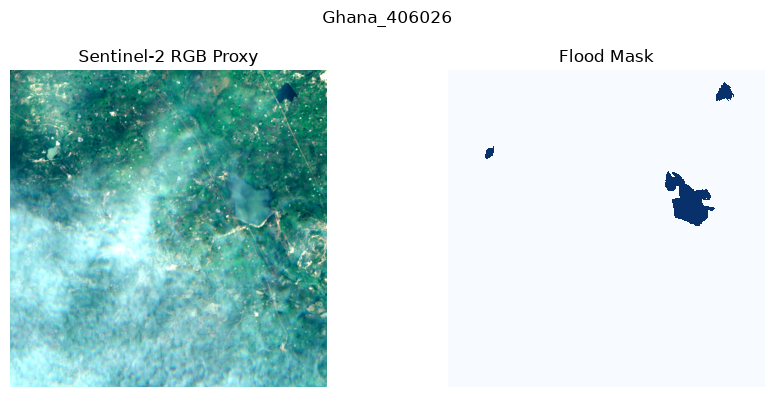

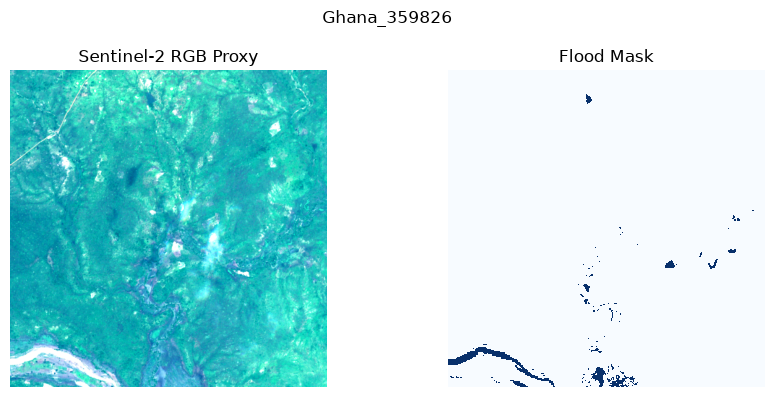

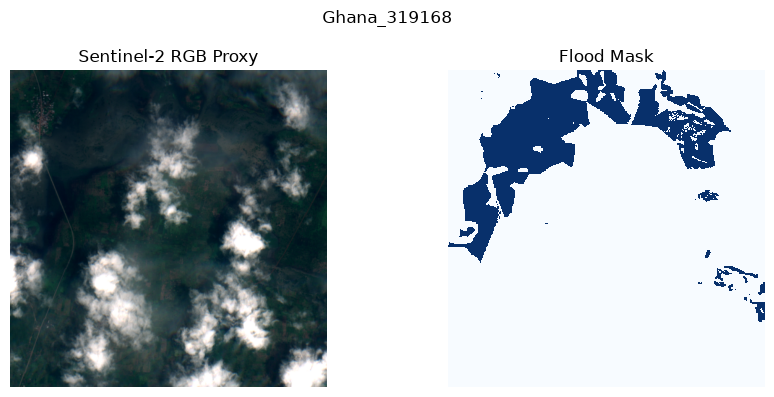

In [11]:
def rgb_from_sentinel2(x):
    # Approximate natural-color proxy from Sentinel-2 B04/B03/B02 if available.
    # The loader returns all 13 bands in source order, so this is an inspection proxy.
    if x.shape[0] >= 4:
        rgb = np.stack([x[3], x[2], x[1]], axis=-1)
    else:
        rgb = np.moveaxis(x[:3], 0, -1)
    lo, hi = np.percentile(rgb, [2, 98])
    return np.clip((rgb - lo) / max(hi - lo, 1e-6), 0, 1)


def plot_flood_sample(sample):
    x = sample['x']
    y = sample['y']
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].imshow(rgb_from_sentinel2(x))
    axes[0].set_title('Sentinel-2 RGB Proxy')
    axes[1].imshow(y, vmin=0, vmax=1, cmap='Blues', interpolation='nearest')
    axes[1].set_title('Flood Mask')
    for ax in axes:
        ax.axis('off')
    fig.suptitle(sample['id'])
    fig.tight_layout()
    return fig

rng = np.random.default_rng(1234)
for idx in rng.choice(len(train_ds), size=min(6, len(train_ds)), replace=False):
    plot_flood_sample(train_ds[int(idx)]);

## 8. Optional: Build Validation and Test Splits

In [12]:
val_ds = build_dataset(cfg, split='val')
test_ds = build_dataset(cfg, split='test')
print('splits:', len(train_ds), len(val_ds), len(test_ds))

splits: 37 8 8


## What To Decide From This Notebook

- Are the flood masks visually aligned with the imagery?
- Is the flood class too sparse for stable label-budget experiments?
- Should this remain a pilot dataset rather than a main benchmark?
- Which examples are visually compelling enough for the lightning talk?